In [1]:
import pandas as pd
from pathlib import Path

# Support both notebook execution from the project folder and from the parent folder.
project_dir = Path.cwd()
candidate_paths = [
    project_dir / 'data' / 'uac_data.csv',
    project_dir / 'UAC_Forecasting_Project' / 'data' / 'uac_data.csv',
    project_dir.parent / 'data' / 'uac_data.csv',
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        'Could not find uac_data.csv. Checked:\n' + '\n'.join(str(p) for p in candidate_paths)
    )

print(f'Loading dataset from: {data_path}')
df = pd.read_csv(data_path)
df.head()


Loading dataset from: C:\Users\kapta\Downloads\UAC-Forecasting-Project-main\UAC-Forecasting-Project-main\UAC_Forecasting_Project\data\uac_data.csv


,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [2]:
df.info()

display(df.describe(include='all').T)

print('\nMissing values:')
display(df.isnull().sum().to_frame('Missing Values'))


<class 'pandas.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    str    
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    str    
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), str(2)
memory usage: 69.5 KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,720,720,"December 21, 2025",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Children apprehended and placed in CBP custody*,720.0,NaN,NaN,NaN,93.523611,72.646625,0.0,12.0,99.0,147.25,333.0
Children in CBP custody,720.0,NaN,NaN,NaN,171.494444,126.354965,7.0,36.0,193.0,263.25,531.0
Children transferred out of CBP custody,720.0,NaN,NaN,NaN,128.668056,97.322012,0.0,14.0,157.0,199.25,440.0
Children in HHS Care,720,642,"2,340",3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Children discharged from HHS Care,720.0,NaN,NaN,NaN,173.406944,125.702841,0.0,19.75,181.0,267.0,505.0



Missing values:


,Missing Values
Date,450
Children apprehended and placed in CBP custody*,450
Children in CBP custody,450
Children transferred out of CBP custody,450
Children in HHS Care,450
Children discharged from HHS Care,450


In [3]:
# Clean the Date column without accidentally deleting valid dates.
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

if df['Date'].notna().sum() == 0:
    raise ValueError('No valid dates were found in the Date column. Inspect df[\'Date\'].head(20).')

df = df.sort_values('Date').reset_index(drop=True)

# Clean the target column while preserving values such as 1,234 or $1,234.50.
target = 'Children in HHS Care'
df[target] = (
    df[target].astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('$', '', regex=False)
    .str.strip()
)
df[target] = pd.to_numeric(df[target], errors='coerce')

print(f'Valid dates: {df["Date"].notna().sum()} / {len(df)}')
print(f'Valid target values: {df[target].notna().sum()} / {len(df)}')


Valid dates: 720 / 1170
Valid target values: 720 / 1170


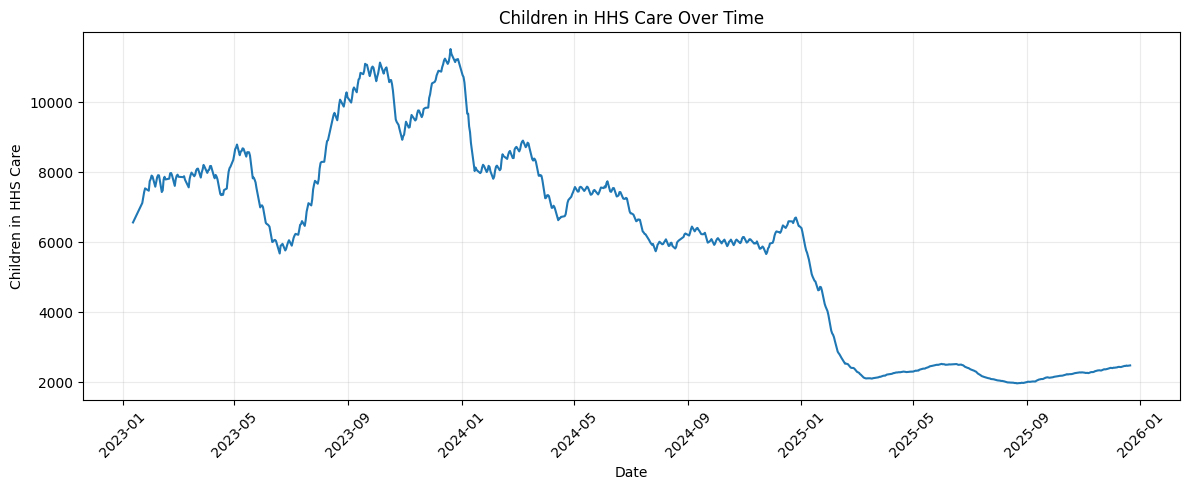

In [4]:
import matplotlib.pyplot as plt

plot_df = df[['Date', 'Children in HHS Care']].dropna().sort_values('Date')

if plot_df.empty:
    raise ValueError(
        'The plot has no valid rows after cleaning. Check the Date and Children in HHS Care columns.'
    )

plt.figure(figsize=(12, 5))
plt.plot(plot_df['Date'], plot_df['Children in HHS Care'], linewidth=1.5)
plt.xlabel('Date')
plt.ylabel('Children in HHS Care')
plt.title('Children in HHS Care Over Time')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


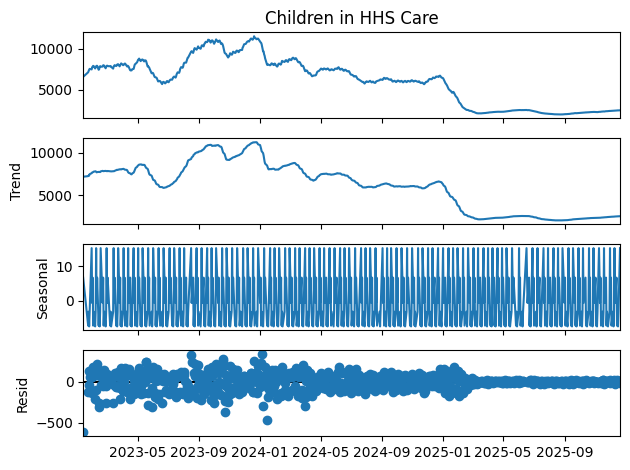

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose

series = (
    df[['Date', 'Children in HHS Care']]
    .dropna()
    .set_index('Date')['Children in HHS Care']
    .sort_index()
)

if len(series) < 14:
    raise ValueError('At least 14 valid observations are recommended for period=7 seasonal decomposition.')

result = seasonal_decompose(series, model='additive', period=7, extrapolate_trend='freq')
result.plot()
plt.tight_layout()
plt.show()
